# YELO - Custom Garbage Detection Model (Google Colab)

## Note for the evaluator

**This notebook has already been executed. All outputs below are real** - the
training logs, accuracy scores, plots, and sample predictions are the actual
results from our training run on 24 July 2026. Nothing needs to be re-run to
review it.

Read it top to bottom: each code cell is preceded by a markdown cell explaining
*what* it does and *why* we chose that approach.

### What this notebook produces

| | |
|---|---|
| **Dataset** | TACO (Trash Annotations in Context), Roboflow v16, ~3,597 images |
| **Base model** | `yolov8s.pt`, pretrained on COCO |
| **Method** | Transfer learning + data augmentation |
| **Hardware** | Google Colab free T4 GPU |
| **Training** | 50 epochs, imgsz 640, batch 16, patience 15 |
| **Output** | `best.pt`, renamed `yolo_garbage.pt` in the project repo |

### Results achieved (see Cell 6 output)

| Metric | Value |
|---|---|
| mAP@0.5 | 0.513 |
| mAP@0.5:0.95 | 0.366 |
| Precision | 0.713 |
| Recall | 0.436 |

### To re-run it yourself

You need a free Roboflow account for an API key (Cell 3 has a placeholder where
it goes) and a Colab runtime set to **T4 GPU**
(Runtime -> Change runtime type -> T4 GPU). A full run takes roughly one hour.

> Our own API key has been removed from this notebook for security. Replace
> `PASTE_YOUR_ROBOFLOW_API_KEY` in Cell 3 with your own.

---


# YELO - Custom Garbage Detection Model (Google Colab)

This notebook trains YELO's **own** garbage/litter detector to replace the
generic pretrained model. The output is a single file, `best.pt`, that plugs
straight into the YELO inference gateway.

### The whole recipe in one glance
| Step | What | Why |
|---|---|---|
| **Data** | TACO - *Trash Annotations in Context* (from Roboflow Universe) | Real-world litter photos, exactly our use-case |
| **Model** | YOLOv8s (small), pretrained on COCO | Fast on free GPU, stable, best-documented |
| **Method** | Transfer learning + data augmentation | Learn garbage with little data; generalise to real cameras |
| **Compute** | Google Colab free **T4 GPU** | Zero cost |
| **Output** | `best.pt` -> saved to Google Drive + downloaded | Drop into the gateway |

### Setup before running
Runtime -> Change runtime type -> Hardware accelerator: **T4 GPU** -> Save.
Then run each cell top to bottom.

## Cell 1 - Confirm the free GPU
Training a neural network on a CPU is painfully slow. Colab gives a free
**Tesla T4 GPU**; this command prints it so we know it's active. If it errors,
redo Runtime -> T4 GPU.

In [1]:
!nvidia-smi

Fri Jul 24 04:59:46 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   62C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## Cell 2 - Install the libraries
- **ultralytics** - the YOLO framework. It handles the whole training loop,
  augmentation, validation metrics, and exporting the model.
- **roboflow** - a small client that downloads our dataset already converted
  to the YOLO format (images + `.txt` label files + a `data.yaml` config).

In [2]:
!pip install ultralytics roboflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.3/45.3 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 20.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 285.0/285.0 kB 24.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 19.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 82.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 135.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 5.6 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 5.0.0.93
    Uninstalling opencv-python-headless-5.0.0.93:
      Successfully uninstalled opencv-python-headless-5.0.0.93
  Attempting uninstall: typer
    Found existing installation: typer 0.26.8
    Uninstalling typer-0.26.8:
      Successfully uninstalled typer-0.26.8


## Cell 3 - Download the dataset (TACO)

**Dataset: TACO - Trash Annotations in Context**, hosted on Roboflow Universe
(`mohamed-traore-2ekkp/taco-trash-annotations-in-context`, version 16 -
the *resize-640, 3x augmented, all-classes* release, ~3,597 images across a
train / valid / test split).

**Why TACO?** It is a well-known academic litter dataset of *real* rubbish
photographed in real environments (streets, parks, beaches) - not studio
objects. That matches a society CCTV camera far better than a generic
object dataset, so the model learns what littering actually looks like.

We request it in **YOLOv8 format**, which Roboflow delivers as: an `images/`
folder, a `labels/` folder (one `.txt` per image with `class x y w h` boxes),
and a `data.yaml` listing the class names and split paths.

In [3]:
from roboflow import Roboflow

# NOTE: this API key is personal - regenerate it in Roboflow after the demo.
rf = Roboflow(api_key="PASTE_YOUR_ROBOFLOW_API_KEY")
project = rf.workspace("mohamed-traore-2ekkp").project("taco-trash-annotations-in-context")
version = project.version(16)                 # v16 = resize640, 3x aug, all classes
dataset = version.download("yolov8")          # download in YOLOv8 detection format

print("Dataset downloaded to:", dataset.location)

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to TACO:-Trash-Annotations-in-Context-Dataset-16 in yolov8:: 100%|██████████| 7204/7204 [00:03<00:00, 1997.54it/s]


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Dataset downloaded to: /content/TACO:-Trash-Annotations-in-Context-Dataset-16


## Cell 4 - Inspect every trash class
The dataset's `data.yaml` defines the list of object classes the model will
learn to detect. TACO has **many** litter types (bottles, cans, cigarettes,
plastic bags, cups, wrappers, ...). We print them all, and also build the exact
comma-separated string we'll later paste into the gateway's
`YELO_WASTE_CLASSES` setting so its littering logic recognises these classes.

In [4]:
import yaml

with open(f"{dataset.location}/data.yaml") as f:
    data_cfg = yaml.safe_load(f)

# 'names' can be a list or an index->name dict depending on the export.
names = data_cfg["names"]
class_names = list(names.values()) if isinstance(names, dict) else list(names)

print("Number of trash classes:", len(class_names))
print("-" * 40)
for i, name in enumerate(class_names):
    print(f"{i:>2}: {name}")
print("-" * 40)

# Copy this whole line into services/inference/.env later.
waste_classes_env = ",".join(str(n).lower() for n in class_names)
print("\nYELO_WASTE_CLASSES=" + waste_classes_env)

Number of trash classes: 1
----------------------------------------
 0: trash
----------------------------------------

YELO_WASTE_CLASSES=trash


## Cell 5 - Train the model (transfer learning + feature engineering)

**Model choice: `yolov8s.pt`** - the *small* YOLOv8, already pretrained on the
COCO dataset. We do **transfer learning**: instead of training from scratch
(which needs huge data and time), we start from those pretrained weights -
the network already knows edges, shapes, and textures - and only *fine-tune*
it to recognise garbage. Far less data, far faster, better accuracy.

**Feature engineering - data augmentation.** For images, feature engineering
means synthetically varying the training photos each epoch so the model sees
endless realistic variations and learns the *object*, not the exact pixels.
This directly fights over-fitting and mirrors real camera conditions:

| Augmentation | What it does | Real-world reason |
|---|---|---|
| `hsv_h/s/v` | shifts hue / saturation / brightness | different cameras, lighting, day vs shade |
| `degrees` | small rotations | camera not perfectly level |
| `translate` | shifts image | litter can appear anywhere in frame |
| `scale` | zooms in/out | near vs far litter |
| `fliplr` | horizontal flip | litter has no fixed orientation |
| `mosaic` | stitches 4 images into 1 | more objects/context per training step |
| `erasing` | randomly erases patches | robust to partial occlusion |

**Key training settings:** `epochs=50` (50 full passes over the data),
`imgsz=640` (training resolution), `batch=16` (images per step),
`patience=15` (early-stop if 15 epochs bring no improvement - saves time and
prevents over-fitting).

In [5]:
from ultralytics import YOLO

model = YOLO("yolov8s.pt")          # pretrained COCO weights = transfer-learning start

results = model.train(
    data=f"{dataset.location}/data.yaml",
    epochs=50,
    imgsz=640,
    batch=16,
    patience=15,
    project="yelo_garbage",
    name="run1",
    # ---- feature engineering / data augmentation ----
    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,
    degrees=10,
    translate=0.1,
    scale=0.5,
    fliplr=0.5,
    mosaic=1.0,
    erasing=0.4,
)

# Capture the REAL output folder Ultralytics used, so later cells never guess
# the path (guessing the path is what caused the earlier file-not-found error).
save_dir = str(results.save_dir)
print("\nTrained model + plots saved in:", save_dir)

Ultralytics 8.4.104 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/TACO:-Trash-Annotations-in-Context-Dataset-16/data.yaml, degrees=10, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=run1, nbs=64, nms=F

## Cell 6 - Measure accuracy (mAP)
We validate the **best** saved weights on the validation split.
**mAP = mean Average Precision** - the standard object-detection score
(0 to 1, higher is better). `mAP@0.5` is the common headline number;
`mAP@0.5:0.95` is stricter. Screenshot this output for the report.

In [6]:
import os

best_path = os.path.join(save_dir, "weights", "best.pt")
best = YOLO(best_path)                 # evaluate the best checkpoint, not the last
metrics = best.val()
print("mAP@0.5:0.95 =", metrics.box.map)
print("mAP@0.5      =", metrics.box.map50)

Ultralytics 8.4.104 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2423.2±787.0 MB/s, size: 83.7 KB)
val: Scanning /content/TACO:-Trash-Annotations-in-Context-Dataset-16/valid/labels.cache... 299 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 299/299 104.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 19/19 3.2it/s 5.9s
                   all        299       1014      0.713      0.435      0.512      0.367
Speed: 2.4ms preprocess, 10.0ms inference, 0.0ms loss, 1.4ms postprocess per image
Results saved to /content/runs/detect/val
mAP@0.5:0.95 = 0.366557231597227
mAP@0.5      = 0.5123335615640712


## Cell 7 - Training result plots
Ultralytics auto-generates these charts. They are excellent evidence for the
report and viva:
- `results.png` - loss and mAP curves over the epochs (should trend the right way)
- `confusion_matrix.png` - which classes get confused with which
- `val_batch0_pred.jpg` - the model's actual predictions on validation images

/content/runs/detect/yelo_garbage/run1/results.png


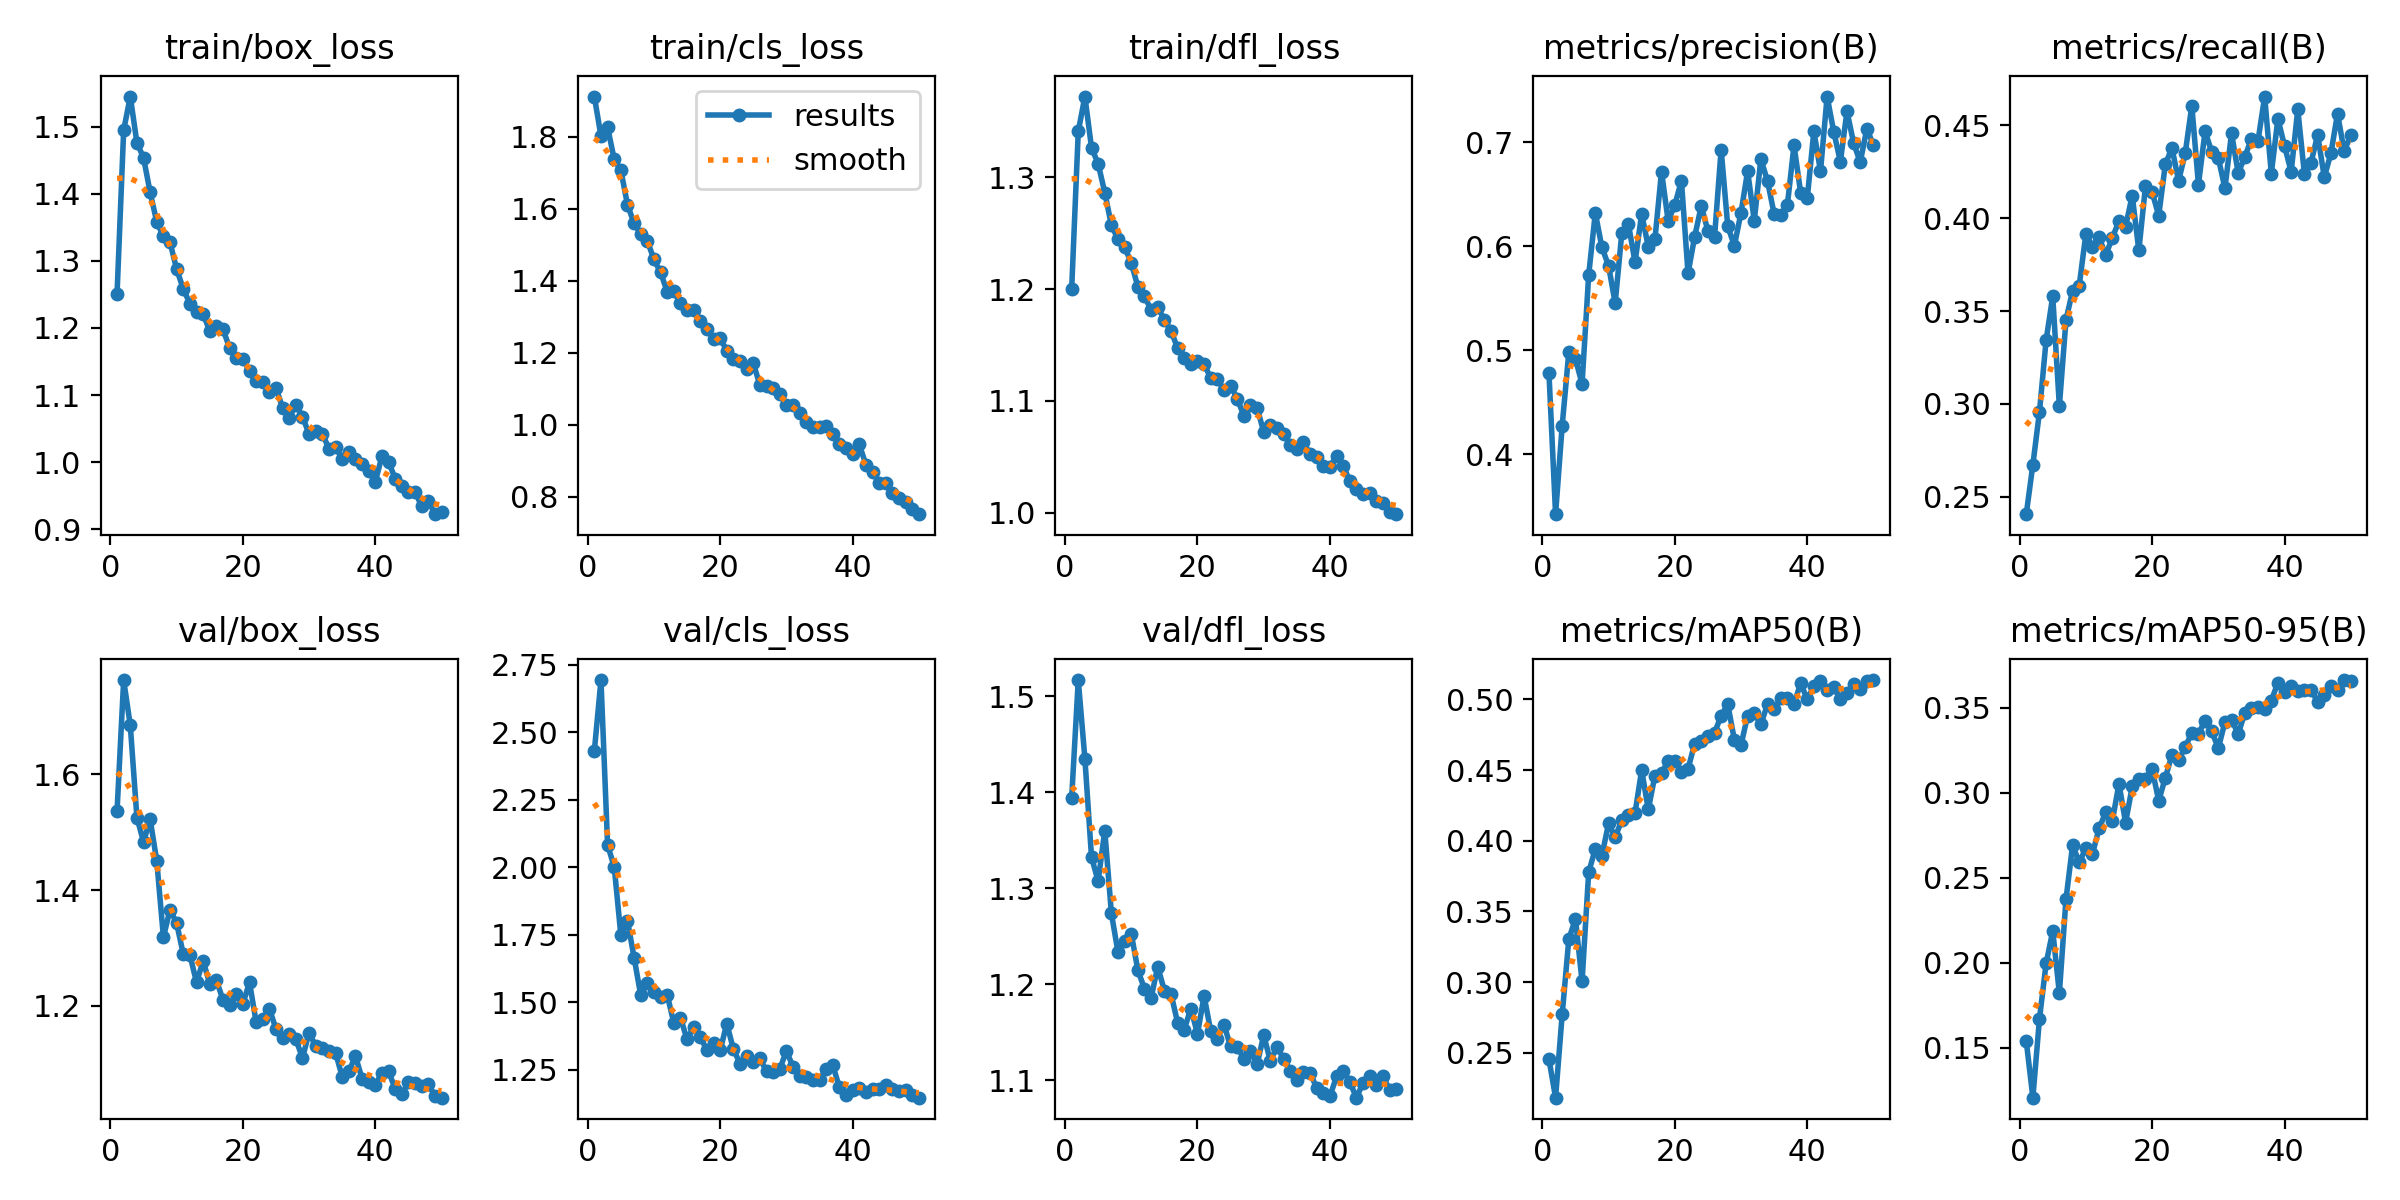

/content/runs/detect/yelo_garbage/run1/confusion_matrix.png


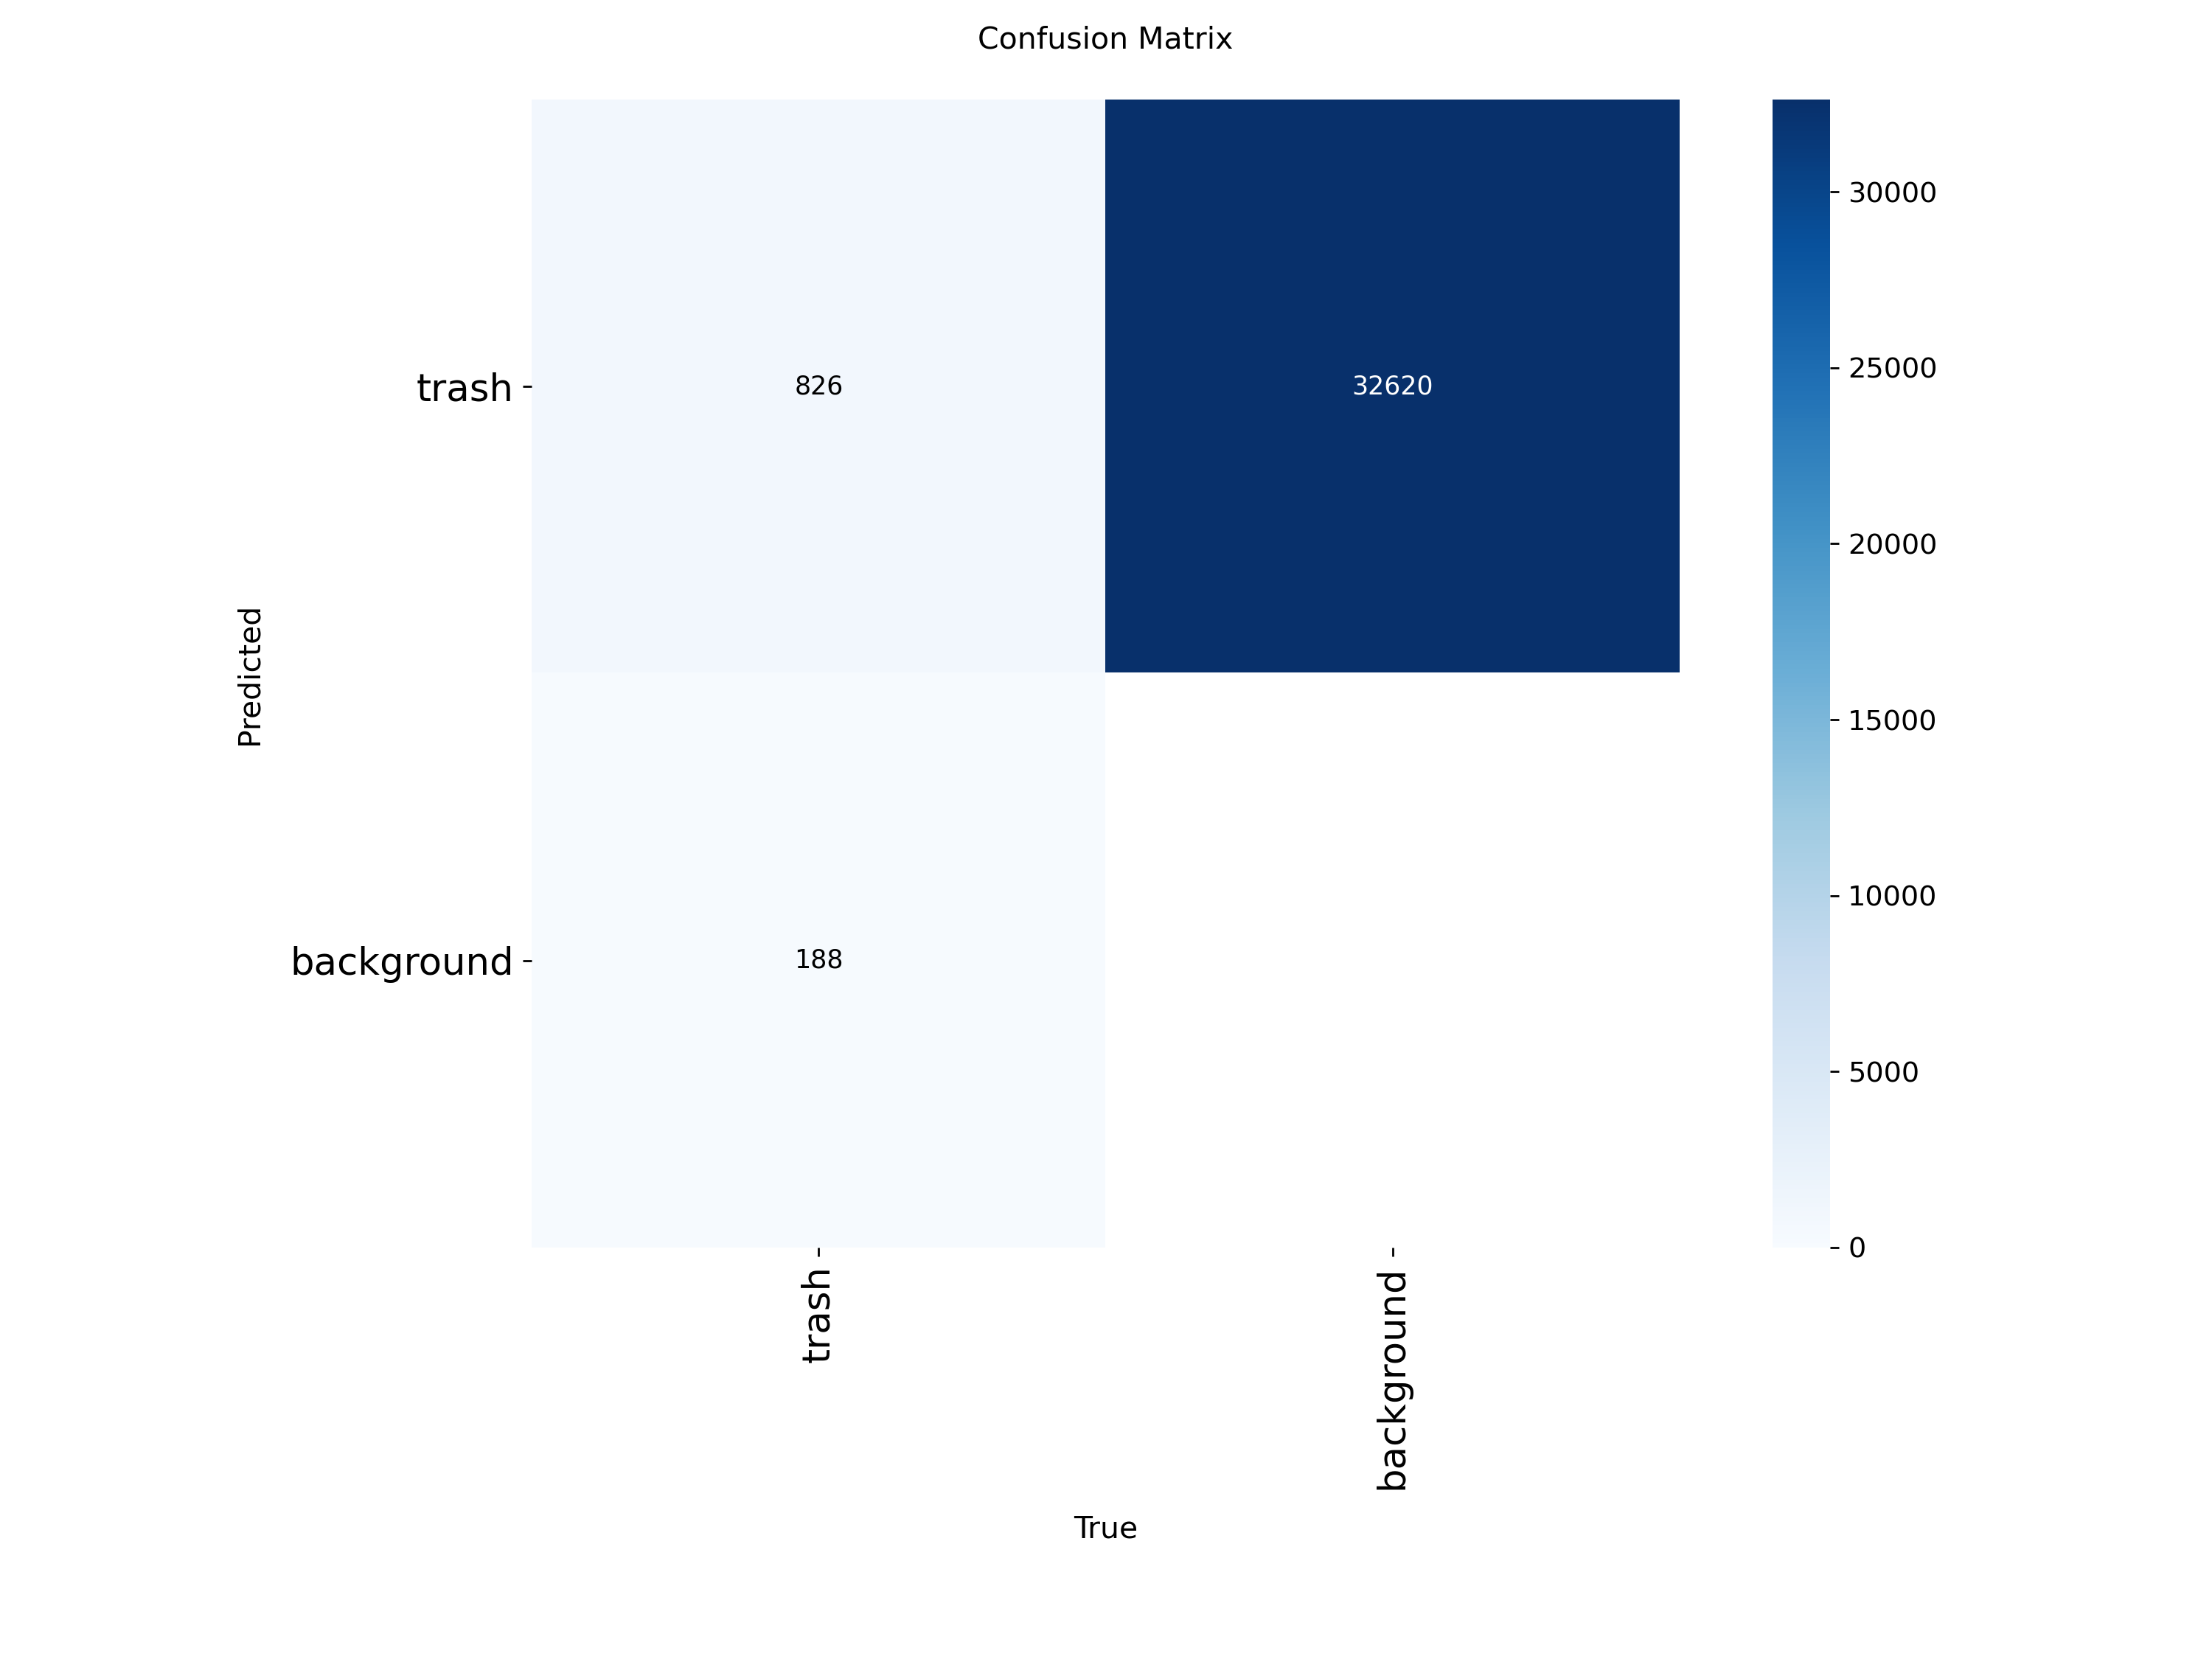

/content/runs/detect/yelo_garbage/run1/val_batch0_pred.jpg


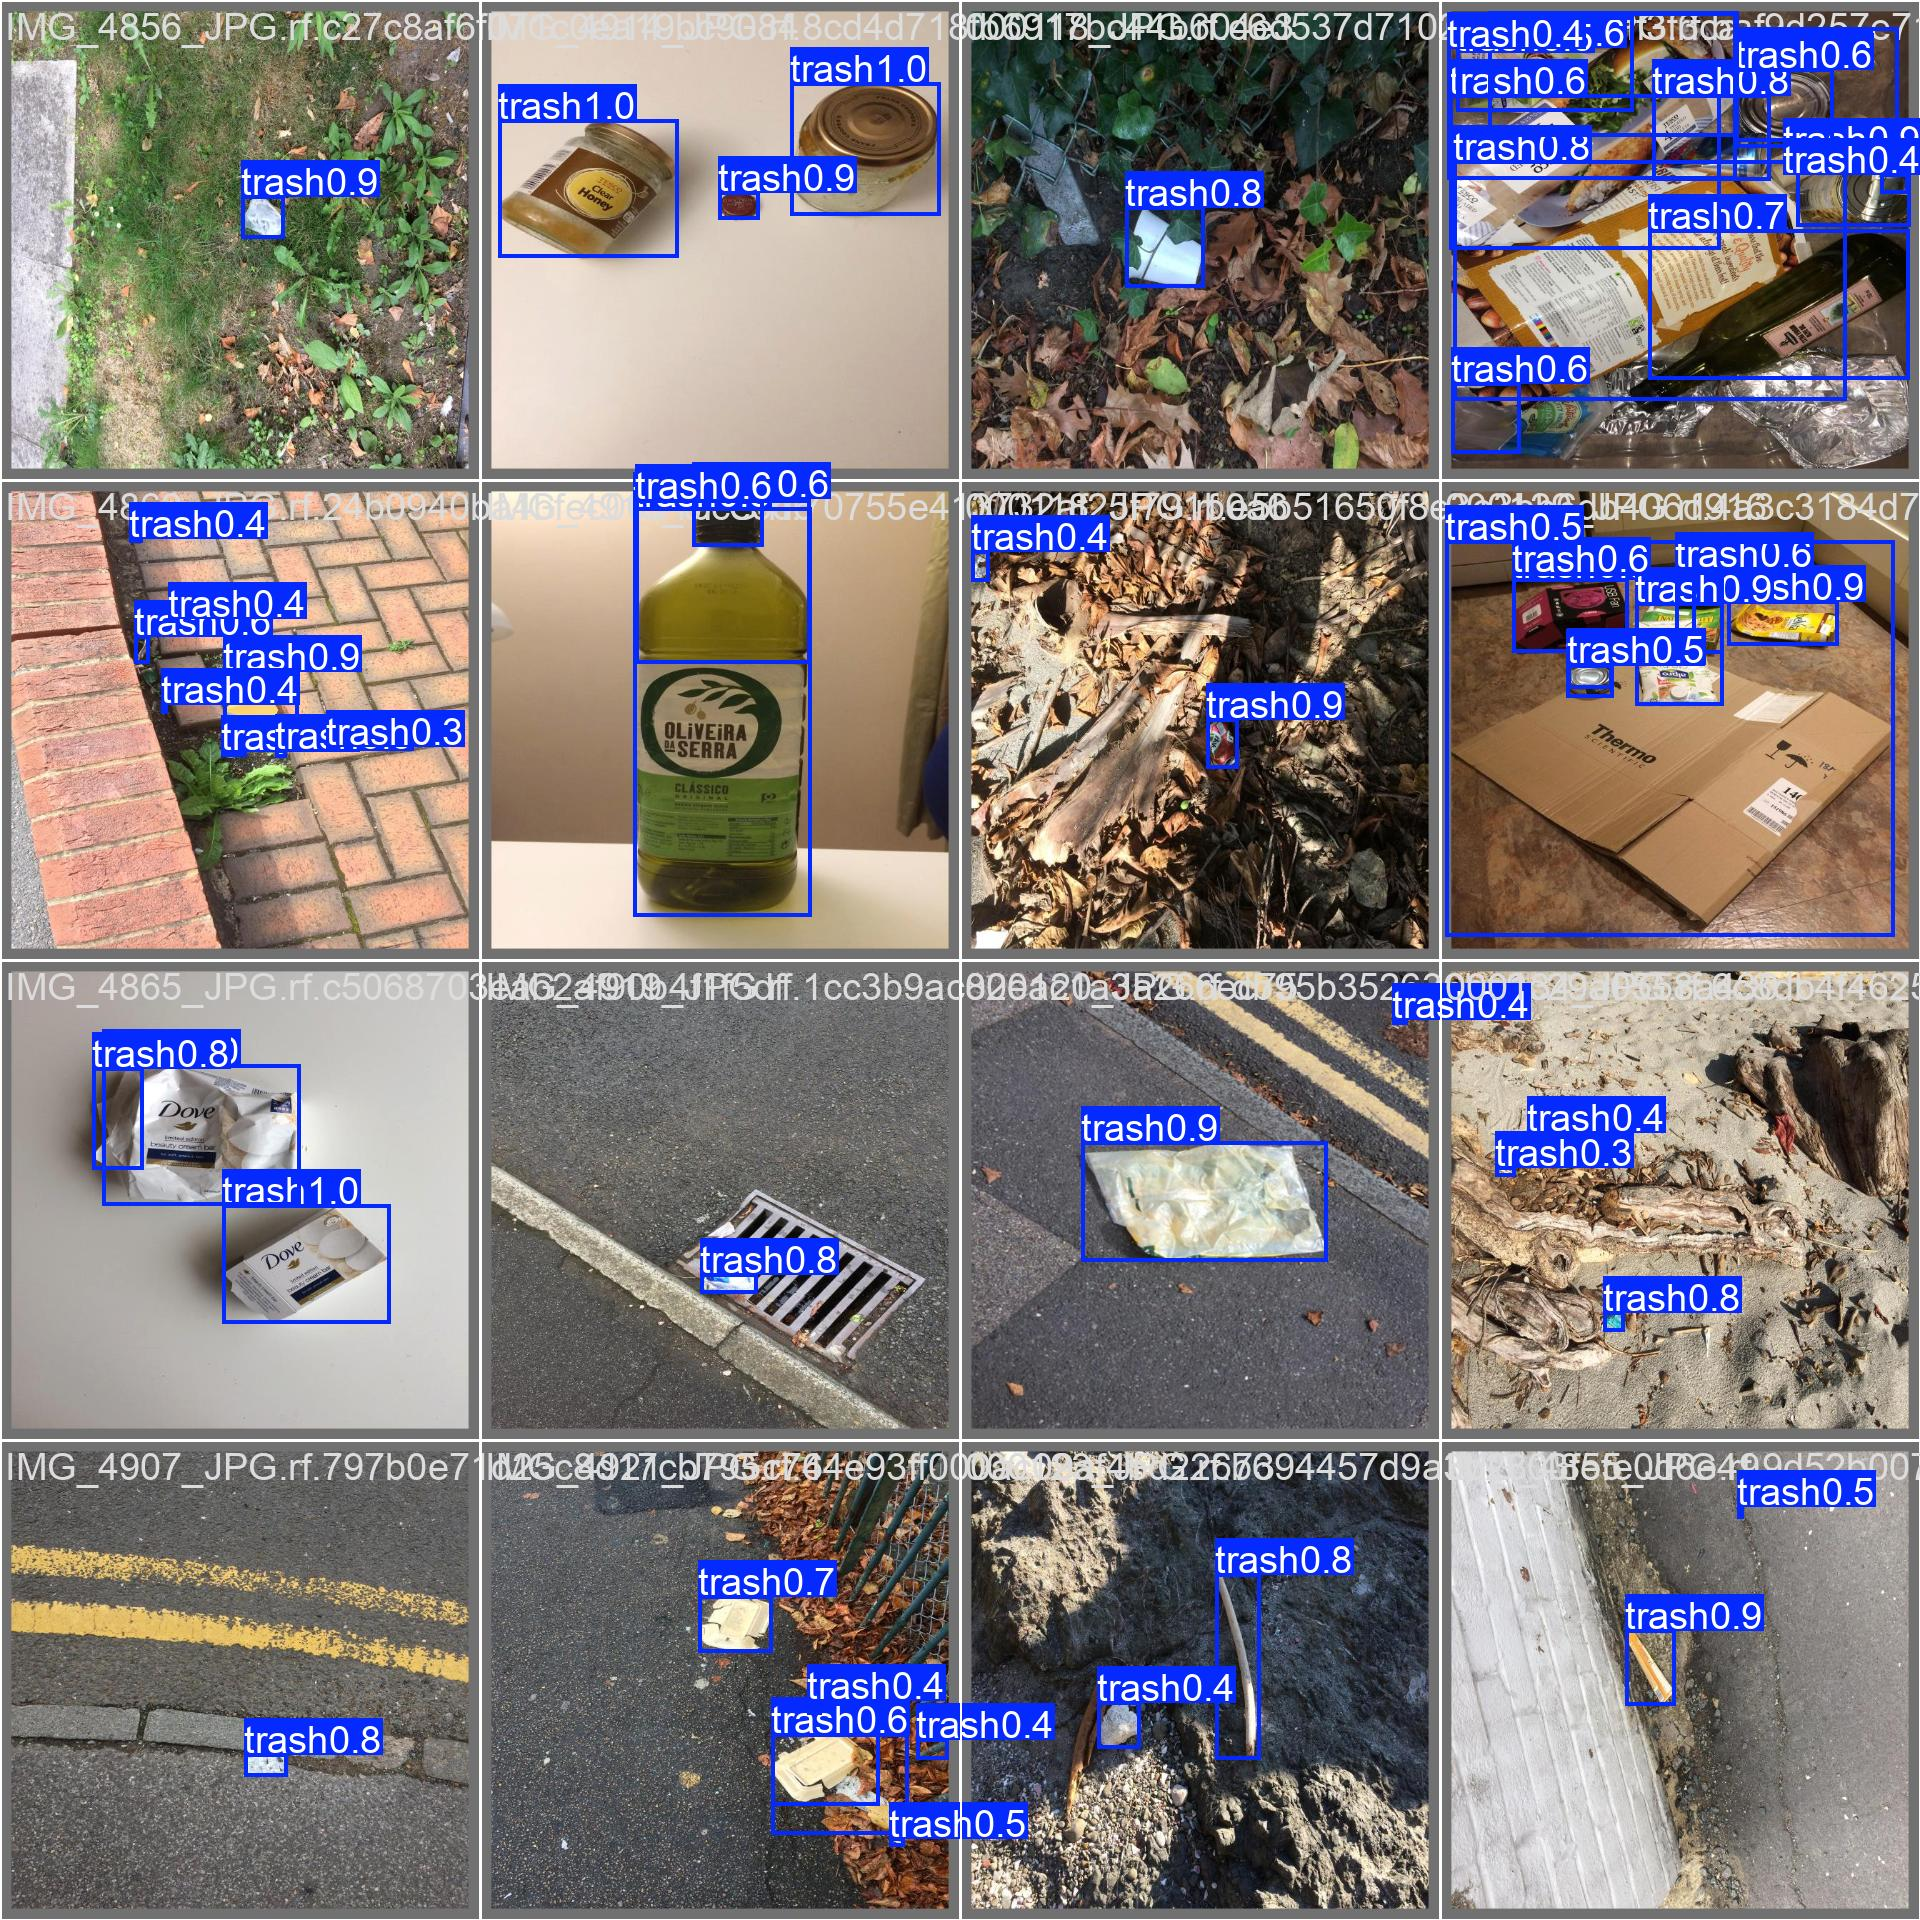

In [7]:
import os
from IPython.display import Image, display

for img in ["results.png", "confusion_matrix.png", "val_batch0_pred.jpg"]:
    path = os.path.join(save_dir, img)
    if os.path.exists(path):
        print(path)
        display(Image(path))
    else:
        print("(not found, skipping):", path)

## Cell 8 - Visual test on real dataset photos
We run the trained model on a few images straight from the dataset's test
split (no manual upload needed) and show the boxes it drew. This is the
'does it actually detect garbage?' proof.

Testing on: ['/content/TACO:-Trash-Annotations-in-Context-Dataset-16/test/images/000001_JPG.rf.1cebaa7292e525c3616c1e6626718cee.jpg', '/content/TACO:-Trash-Annotations-in-Context-Dataset-16/test/images/000002_jpg.rf.f0c70585c8465d2c8a31110463f678ce.jpg', '/content/TACO:-Trash-Annotations-in-Context-Dataset-16/test/images/000004_jpg.rf.f220eaab0f36226385a34eb0708f9936.jpg']

0: 640x640 7 trashs, 28.8ms
1: 640x640 2 trashs, 28.8ms
2: 640x640 1 trash, 28.8ms
Speed: 3.0ms preprocess, 28.8ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict


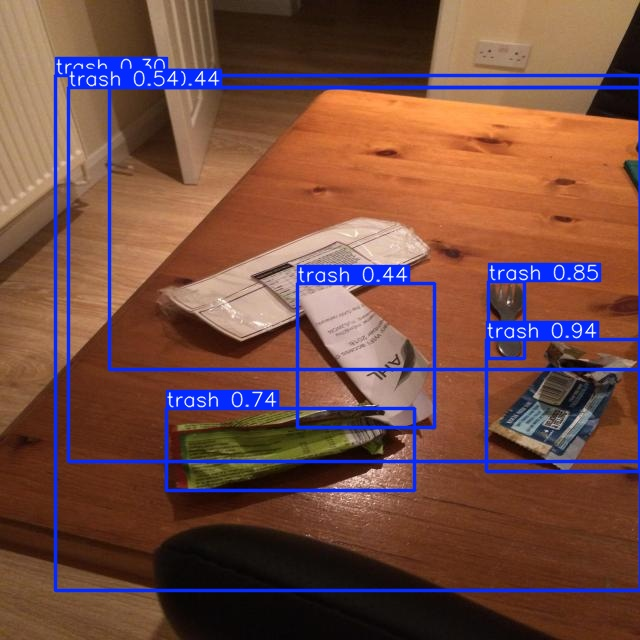

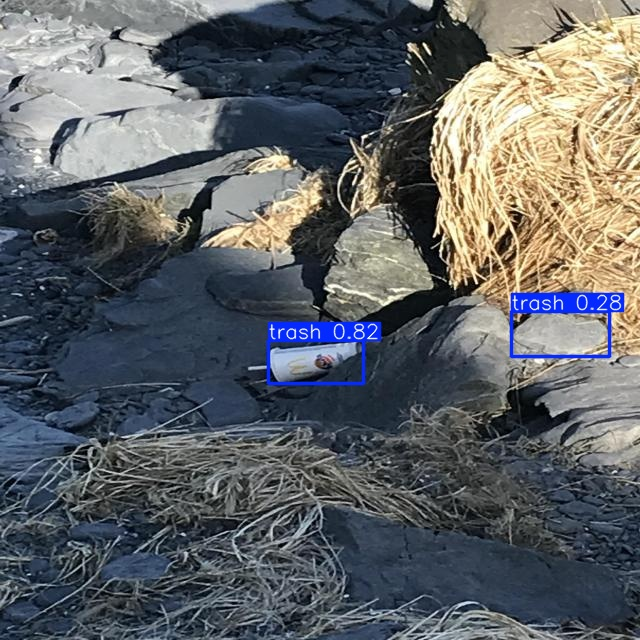

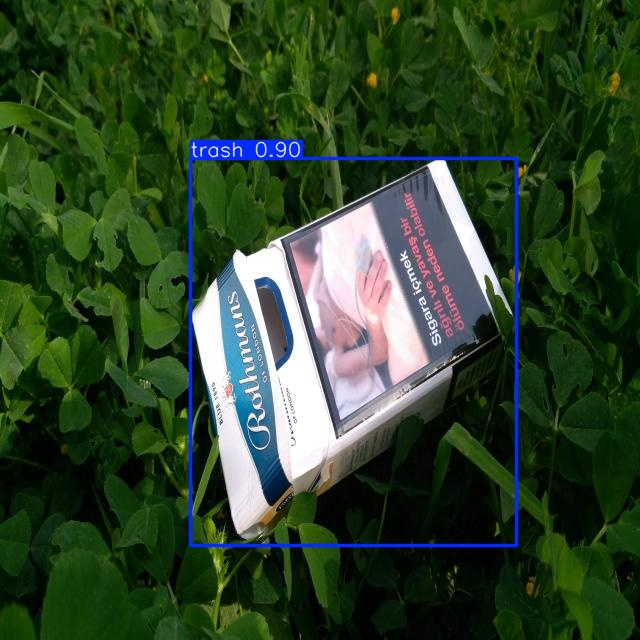

In [8]:
import os, glob
from IPython.display import Image, display

# Pick 3 images from the test split (fall back to valid split).
sample_dir = None
for candidate in ["test/images", "valid/images"]:
    p = os.path.join(dataset.location, candidate)
    if os.path.isdir(p):
        sample_dir = p
        break

samples = sorted(glob.glob(os.path.join(sample_dir, "*")))[:3] if sample_dir else []
print("Testing on:", samples)

preds = best.predict(samples, save=True, conf=0.25)   # conf=0.25 keeps weaker but real detections
for r in preds:
    display(Image(os.path.join(r.save_dir, os.path.basename(r.path))))

## Cell 9 - Save the model (Google Drive + laptop)
The trained model is one file: `best.pt`. We save it two ways so it can never
be lost:
1. Copy to **Google Drive** (`MyDrive/YELO/yolo_garbage.pt`) - survives even if
   the Colab session disconnects.
2. **Download** it to the laptop for immediate use in the gateway.

In [9]:
import os, shutil
from google.colab import drive, files

best_path = os.path.join(save_dir, "weights", "best.pt")
print("Model file:", best_path, "| exists:", os.path.exists(best_path))

# 1) Google Drive copy
drive.mount("/content/drive")
drive_dir = "/content/drive/MyDrive/YELO"
os.makedirs(drive_dir, exist_ok=True)
drive_target = os.path.join(drive_dir, "yolo_garbage.pt")
shutil.copy(best_path, drive_target)
print("Saved to Google Drive:", drive_target)

# 2) Direct download to your laptop
files.download(best_path)

Model file: /content/runs/detect/yelo_garbage/run1/weights/best.pt | exists: True
Mounted at /content/drive
Saved to Google Drive: /content/drive/MyDrive/YELO/yolo_garbage.pt


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## After download - plug the model into YELO (on your laptop)
1. Put the downloaded `best.pt` at the repo root, renamed to `yolo_garbage.pt`.
2. In `services/inference/.env` add these two lines
   (use the exact `YELO_WASTE_CLASSES=...` line printed by **Cell 4**):
   ```
   YELO_MODEL_PATH=yolo_garbage.pt
   YELO_WASTE_CLASSES=<paste the line from Cell 4>
   ```
3. Restart the gateway: `python server.py`
4. Open http://localhost:8000/health and confirm
   `"modelName": "yolo_garbage.pt"` and `"modelReady": true`.

### One-line summary for the viva
> "We built our own detector: took the **TACO** real-world litter dataset from
> Roboflow, applied **data-augmentation feature engineering** (HSV, rotation,
> scale, flip, mosaic, random-erase), and **transfer-learned** a COCO-pretrained
> **YOLOv8-small** on Colab's free **T4 GPU** for 50 epochs. The resulting
> `best.pt` replaces the generic model in our inference gateway."